<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Modules/Handson/ML_MOR_WEEKDAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- 1) plot the data - all the idea  -->

*   lINEARITY - the relationship btw in the independant var and the dep var is linear in nature indp var and dep var -> relation linear
*   Independence - Observations are independent of each other - randomized (pur, )
* Homoscedasticity (const variance) the variance is constant across all indep var (behvaior check) - model follows properl linear beh (check)
* Normality of Residuals - normally dist, shapiro -wilk, plot, Q-Q plot
* No perect multicollinearity  (indp var - no corr) - target




In [ ]:
#Example programs

import numpy as np

arr = np.array([1,2,3,4,5,6])
arr.reshape(2,3) #rows, 3 columns

arr.reshape(-1, 2) #-1

array([[1, 2],
       [3, 4],
       [5, 6]])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
weeks_data = [1,2,3,4,5]
sales_data = [2,4,5,4,5]

df = pd.DataFrame({"weeks":weeks_data,
                  "sales":sales_data})
df

,weeks,sales
0,1,2
1,2,4
2,3,5
3,4,4
4,5,5


In [ ]:
#feature
X = df['weeks'].values
X

#Target
Y = df['sales'].values
Y

array([2, 4, 5, 4, 5])

In [ ]:
mean_x = np.mean(X)
mean_y = np.mean(Y)
n = len(X) #how many data record exist?    looping?
#counter
numer = 0
denom = 0
for i in range(n):
  numer += (X[i] - mean_x) * (Y[i] - mean_y)
  denom += (X[i] - mean_x) ** 2

m = numer/denom
c = mean_y - (m * mean_x)
print(f"Slope(m) : {m}\ny_intercept : {c}")

Slope(m) : 0.6
y_intercept : 2.2


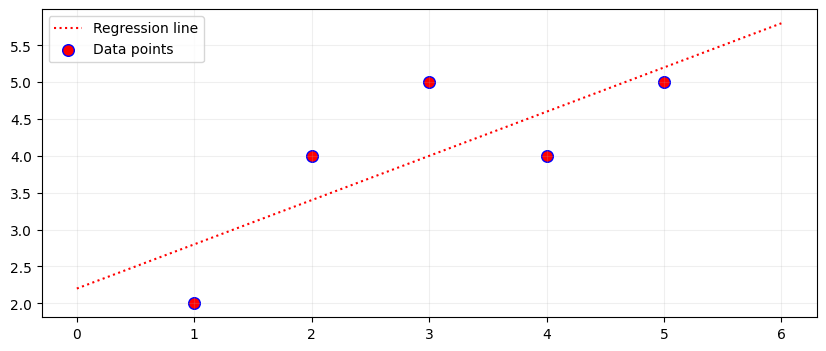

In [ ]:
#visual confirmation?
max_x = np.max(X) + 1
min_x = np.min(X) - 1

x = np.linspace(min_x,max_x)

y = (m * x) + c
plt.figure(figsize=(10,4))
plt.plot(x,y,color='red',label='Regression line', linestyle=":")
plt.scatter(X,Y, color='red',edgecolor='blue',s=70,label='Data points')
plt.legend()
plt.grid(True,alpha=0.2)

In [ ]:
ss_tot = 0
ss_sse = 0

for i in range(n):
  y_pred = (m * X[i]) + c #once
  ss_tot += (Y[i] - mean_y) ** 2
  ss_sse += (Y[i] - y_pred) ** 2

r2 = 1 - (ss_sse/ss_tot)
r2

np.float64(0.6000000000000001)

In [ ]:
from sklearn.linear_model import LinearRegression

X = X.reshape((n,1))
X

reg = LinearRegression()
reg = reg.fit(X,Y) #run the model

In [ ]:
y_pred = (m * X) + c
r2_score = reg.score(X,Y)
r2_score

0.6000000000000001

In [ ]:
reg.coef_

array([0.6])

In [ ]:
reg.intercept_

np.float64(2.2)

In [ ]:
import pandas as pd


data = pd.DataFrame({"Area_house":[1200,3500,5600,4500,2300,4560,2340,3450],
                     "locality":["good","bad","moderate","bad","bad","moderate","good","bad"],
                     "no_bhk":[3,2,4,2,3,4,2,3],
                     "Price_House":[1.2, 3.2, 4.5,1,2,1,3.2,4]})

data

,Area_house,locality,no_bhk,Price_House
0,1200,good,3,1.2
1,3500,bad,2,3.2
2,5600,moderate,4,4.5
3,4500,bad,2,1.0
4,2300,bad,3,2.0
5,4560,moderate,4,1.0
6,2340,good,2,3.2
7,3450,bad,3,4.0


In [ ]:
#Namaste Folks, Let's start in 2-4 minutes
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving headbrain.csv to headbrain.csv


{'headbrain.csv': b'Gender,Age Range,Head Size(cm^3),Brain Weight(grams)\n1,1,4512,1530\n1,1,3738,1297\n1,1,4261,1335\n1,1,3777,1282\n1,1,4177,1590\n1,1,3585,1300\n1,1,3785,1400\n1,1,3559,1255\n1,1,3613,1355\n1,1,3982,1375\n1,1,3443,1340\n1,1,3993,1380\n1,1,3640,1355\n1,1,4208,1522\n1,1,3832,1208\n1,1,3876,1405\n1,1,3497,1358\n1,1,3466,1292\n1,1,3095,1340\n1,1,4424,1400\n1,1,3878,1357\n1,1,4046,1287\n1,1,3804,1275\n1,1,3710,1270\n1,1,4747,1635\n1,1,4423,1505\n1,1,4036,1490\n1,1,4022,1485\n1,1,3454,1310\n1,1,4175,1420\n1,1,3787,1318\n1,1,3796,1432\n1,1,4103,1364\n1,1,4161,1405\n1,1,4158,1432\n1,1,3814,1207\n1,1,3527,1375\n1,1,3748,1350\n1,1,3334,1236\n1,1,3492,1250\n1,1,3962,1350\n1,1,3505,1320\n1,1,4315,1525\n1,1,3804,1570\n1,1,3863,1340\n1,1,4034,1422\n1,1,4308,1506\n1,1,3165,1215\n1,1,3641,1311\n1,1,3644,1300\n1,1,3891,1224\n1,1,3793,1350\n1,1,4270,1335\n1,1,4063,1390\n1,1,4012,1400\n1,1,3458,1225\n1,1,3890,1310\n1,2,4166,1560\n1,2,3935,1330\n1,2,3669,1222\n1,2,3866,1415\n1,2,3393,11

In [ ]:
data = pd.read_csv("/content/headbrain.csv")
data.head(5)

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [ ]:
data['Gender'].value_counts()
data['Age Range'].value_counts()

,count
Age Range,
2,127
1,110


In [ ]:
#Feature-
X = data['Head Size(cm^3)'].values
X = X.reshape(-1,1)
X

array([[4512],
       [3738],
       [4261],
       [3777],
       [4177],
       [3585],
       [3785],
       [3559],
       [3613],
       [3982],
       [3443],
       [3993],
       [3640],
       [4208],
       [3832],
       [3876],
       [3497],
       [3466],
       [3095],
       [4424],
       [3878],
       [4046],
       [3804],
       [3710],
       [4747],
       [4423],
       [4036],
       [4022],
       [3454],
       [4175],
       [3787],
       [3796],
       [4103],
       [4161],
       [4158],
       [3814],
       [3527],
       [3748],
       [3334],
       [3492],
       [3962],
       [3505],
       [4315],
       [3804],
       [3863],
       [4034],
       [4308],
       [3165],
       [3641],
       [3644],
       [3891],
       [3793],
       [4270],
       [4063],
       [4012],
       [3458],
       [3890],
       [4166],
       [3935],
       [3669],
       [3866],
       [3393],
       [4442],
       [4253],
       [3727],
       [3329],
       [34

In [ ]:
#Target-
Y = data['Brain Weight(grams)'].values
Y

array([1530, 1297, 1335, 1282, 1590, 1300, 1400, 1255, 1355, 1375, 1340,
       1380, 1355, 1522, 1208, 1405, 1358, 1292, 1340, 1400, 1357, 1287,
       1275, 1270, 1635, 1505, 1490, 1485, 1310, 1420, 1318, 1432, 1364,
       1405, 1432, 1207, 1375, 1350, 1236, 1250, 1350, 1320, 1525, 1570,
       1340, 1422, 1506, 1215, 1311, 1300, 1224, 1350, 1335, 1390, 1400,
       1225, 1310, 1560, 1330, 1222, 1415, 1175, 1330, 1485, 1470, 1135,
       1310, 1154, 1510, 1415, 1468, 1390, 1380, 1432, 1240, 1195, 1225,
       1188, 1252, 1315, 1245, 1430, 1279, 1245, 1309, 1412, 1120, 1220,
       1280, 1440, 1370, 1192, 1230, 1346, 1290, 1165, 1240, 1132, 1242,
       1270, 1218, 1430, 1588, 1320, 1290, 1260, 1425, 1226, 1360, 1620,
       1310, 1250, 1295, 1290, 1290, 1275, 1250, 1270, 1362, 1300, 1173,
       1256, 1440, 1180, 1306, 1350, 1125, 1165, 1312, 1300, 1270, 1335,
       1450, 1310, 1027, 1235, 1260, 1165, 1080, 1127, 1270, 1252, 1200,
       1290, 1334, 1380, 1140, 1243, 1340, 1168, 13

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

In [ ]:
lr = LinearRegression()
lr = lr.fit(X_train, y_train)
lr

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
y_pred

array([1364.09410111, 1112.00412937, 1223.89433073, 1337.13260681,
       1324.19108954, 1437.69898056, 1187.22669848, 1253.28235952,
       1277.27808945, 1235.48777328, 1265.95426185, 1335.78453209,
       1193.42784217, 1363.55487123, 1173.47633638, 1436.62052079,
       1259.75311816, 1352.23104362, 1328.77454357, 1270.80733082,
       1218.23241693, 1136.26947424, 1343.3337505 , 1229.55624453,
       1342.79452061, 1272.15540554, 1217.4235721 , 1246.54198595,
       1466.54777947, 1291.56768143, 1248.1596756 , 1313.67610676,
       1145.43638231, 1500.78887724, 1355.46642294, 1220.11972153,
       1344.68182521, 1348.72604936, 1285.0969228 , 1216.88434221,
       1286.71461246, 1495.93580826, 1325.26954931, 1186.68746859,
       1348.18681947, 1230.09547442, 1375.95715861, 1184.2609341 ])

In [ ]:
print("="*50)
mse = mean_squared_error(y_test,y_pred)
print(f"mse : {mse:.2f}")
print("="*50)
rmse = np.sqrt(mse)
print(f"RMSE : {rmse:.2f}")
print(f"On average  your predictions are off by '{rmse:.2f}' grams")
print("="*50)
mae = mean_absolute_error(y_test,y_pred)
print(f"mae : {mae:.2f}")
print(f"Your typical overall error in this code is '{mae:.2f}' grams")
print("="*50)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"mape : {mape:.2f}")
print(f"Your predictions are only '{mape:.2f}'% wrong on average (entire data passed!)")
print("="*50)
r2 = r2_score(y_test,y_pred)
print(f"r2 : {r2:.2f}")
print(f"Your model explains 50% of the variations in brain weight")
print(f"50% of brainweight bdiff are exp by head size")
print("="*50)

mse : 5825.46
RMSE : 76.32
On average  your predictions are off by '76.32' grams
mae : 58.96
Your typical overall error in this code is '58.96' grams
mape : 0.05
Your predictions are only '0.05'% wrong on average (entire data passed!)
r2 : 0.50
Your model explains 50% of the variations in brain weight


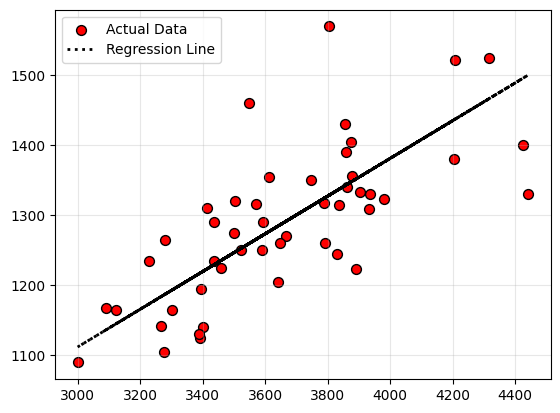

In [ ]:
#Vis
plt.scatter(X_test,y_test,color='red',label='Actual Data',s=50,edgecolors='black')
plt.plot(X_test,y_pred, color='black',linewidth=2, label='Regression Line', linestyle=':')
plt.legend()
plt.grid(True,alpha=0.3)

In [ ]:
head_size = [[4356.675]]
pred_brain_weight = lr.predict(head_size)
pred_brain_weight

array([1477.78398222])

In [ ]:
import numpy as np

#Y = (m1 * area) + (m2 * price) + (m3 * bhk) + c. - best fit line

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def predict_buy_or_not_buy(area,price,bhk,m1,m2,m3,c,thresh=0.5):
  y = (m1*area)+(m2*price)+(m3*bhk) + c
  prob = sigmoid(y)

  label = 1 if prob >= thresh else 0
  return prob, label

m1 = 0.001
m2 = -0.000001
m3 = 0.2
c = -1.5

houses = [
    {"area":1200, "price":500000, "bhk":2},
    {"area":1200, "price":300000, "bhk":3}
]

for i, house in enumerate(houses, start=1):
  prob, label = predict_buy_or_not_buy(house['area'],
                                       house['price'],
                                       house['bhk'],
                                       m1,m2,m3,
                                       c)
  print(f"House{i}: Area:{house['area']}, Price : {house['price']}, BHK: {house['bhk']}")
  print(f"Probability of Buying = {prob}")
  print(f"Decision (0=No/1=Yes) = {label}")
  print("="*30)

House1: Area:1200, Price : 500000, BHK: 2
Probability of Buying = 0.401312339887548
Decision (0=No/1=Yes) = 0
House2: Area:1200, Price : 300000, BHK: 3
Probability of Buying = 0.5
Decision (0=No/1=Yes) = 1


### Logistic regression

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ["buying","maint","doors","persons","lug_boot","safety","class"]
df = pd.read_csv(url,names=columns)
df.head(5)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
#print data set information
print(f"- Total cars : {len(df)}")
print(f"- Features: {len(df.columns)-1}")

- Total cars : 1728
- Features: 6


In [ ]:
#Data analyis
df.head(2)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc


In [ ]:
print("Feature analysis")
for col in df.columns:
  unique_vals = df[col].nunique()
  print(f"\n{col.upper()}")
  print(f"  Categories : {unique_vals}")
  print(f"  Values: {list(df[col].unique())}")
  print(f"  Distribution:\n{df[col].value_counts()}")

Feature analysis

BUYING
  Categories : 4
  Values: ['vhigh', 'high', 'med', 'low']
  Distribution:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

MAINT
  Categories : 4
  Values: ['vhigh', 'high', 'med', 'low']
  Distribution:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

DOORS
  Categories : 4
  Values: ['2', '3', '4', '5more']
  Distribution:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

PERSONS
  Categories : 3
  Values: ['2', '4', 'more']
  Distribution:
persons
2       576
4       576
more    576
Name: count, dtype: int64

LUG_BOOT
  Categories : 3
  Values: ['small', 'med', 'big']
  Distribution:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

SAFETY
  Categories : 3
  Values: ['low', 'med', 'high']
  Distribution:
safety
low     576
med     576
high    576
Name: count, dtype: int64

CLASS
  Categories : 4
  Values: ['unacc', 'acc', 'vgo

In [ ]:
# class_dist = df['class'].value_counts()
# for cls, count in class_dist.items():
#   print(f"cls : {cls}")
#   print(f"count : {count}")

In [ ]:
print("Target variable analyis")
print(f"Original class : {df['class'].unique()}") #2 class
class_dist = df['class'].value_counts()
print()
print(f"Class Distribution")
for cls, count in class_dist.items():
  print(f"  {cls}: {count:,} ({count/len(df)*100:.1f}%)")

Target variable analyis
Original class : ['unacc' 'acc' 'vgood' 'good']

Class Distribution
  unacc: 1,210 (70.0%)
  acc: 384 (22.2%)
  good: 69 (4.0%)
  vgood: 65 (3.8%)


<Axes: xlabel='class'>

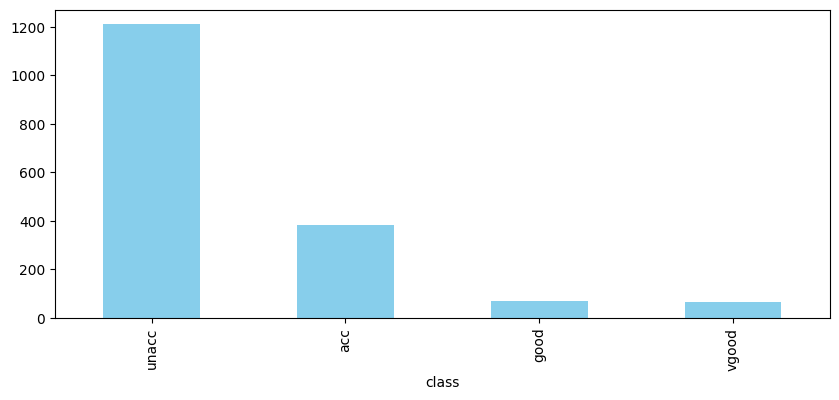

In [ ]:
#visual
plt.figure(figsize=(10,4))
df['class'].value_counts().plot(kind='bar',color='skyblue')

<Axes: xlabel='acceptable'>

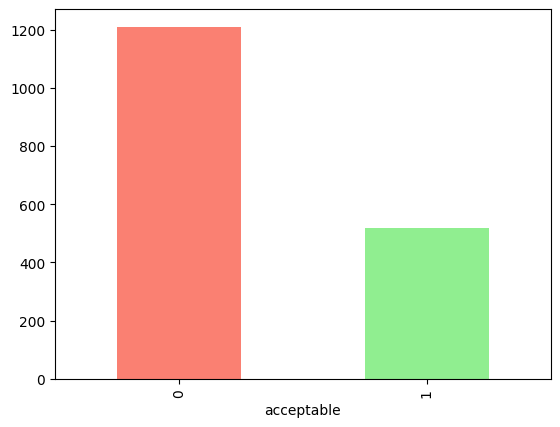

In [ ]:
df['acceptable'] = df['class'].isin(["acc","good","vgood"]).astype(int)
df['acceptable'].value_counts().plot(kind='bar',color=['salmon',"lightgreen"])

In [ ]:
df.head(2)

,buying,maint,doors,persons,lug_boot,safety,class,acceptable
0,vhigh,vhigh,2,2,small,low,unacc,0
1,vhigh,vhigh,2,2,small,med,unacc,0


In [ ]:
#dist per
print(f"  Accept cars : {df['acceptable'].sum():,} ({df['acceptable'].mean()*100:.1f}%)")
print(f"  Not accp : {(1-df['acceptable']).sum():,} ({(1-df['acceptable'].mean())*100:.1f}%)")

  Accept cars : 518 (30.0%)
  Not accp : 1,210 (70.0%)


In [ ]:
X = df.drop(['class','acceptable'], axis=1)
X.head(2)

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med


In [ ]:
y = df['acceptable']
y.head(2)

,acceptable
0,0
1,0


In [ ]:
#see you have to convert string values in to numeric values such that you ml code can understand
print(f"Original feratures (before applting encoding)")
X.head(2)
# X.info()

Original feratures (before applting encoding)


,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med


In [ ]:
print("Applying label encoding.....")
label_encoders = {}
X_encoded = pd.DataFrame()

for column in X.columns:
  le = LabelEncoder()
  X_encoded[column] = le.fit_transform(X[column])
  label_encoders[column] = le

  mapping = dict(zip(le.classes_, le.transform(le.classes_)))
  print(f"\n{column.upper()} encoding:")
  for original, encoded in mapping.items():
    print(f"  {original} ---> {encoded}")

Applying label encoding.....

BUYING encoding:
  high ---> 0
  low ---> 1
  med ---> 2
  vhigh ---> 3

MAINT encoding:
  high ---> 0
  low ---> 1
  med ---> 2
  vhigh ---> 3

DOORS encoding:
  2 ---> 0
  3 ---> 1
  4 ---> 2
  5more ---> 3

PERSONS encoding:
  2 ---> 0
  4 ---> 1
  more ---> 2

LUG_BOOT encoding:
  big ---> 0
  med ---> 1
  small ---> 2

SAFETY encoding:
  high ---> 0
  low ---> 1
  med ---> 2


In [ ]:
X_encoded.head(2)

,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,2,1
1,3,3,0,0,2,2


In [ ]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int64
 1   maint     1728 non-null   int64
 2   doors     1728 non-null   int64
 3   persons   1728 non-null   int64
 4   lug_boot  1728 non-null   int64
 5   safety    1728 non-null   int64
dtypes: int64(6)
memory usage: 81.1 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, stratify=y, random_state=42
)

lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train, y_train) #.fit is your way of sayingf train the model

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [ ]:
print(f"Accuracy : {accuracy:.2f} ({accuracy*100:.2f}%)")
print(f"Precision  : {precision:.2f} ({precision*100:.2f}%)")
print(f"Recall  : {recall:.2f} ({recall*100:.2f}%)")
print(f"F1 Score : {f1:.2f}")

Accuracy : 0.70 (70.23%)
Precision  : 0.51 (50.77%)
Recall  : 0.32 (31.73%)
F1 Score : 0.39


In [ ]:
# Confusion matrix
# is a table that shows how well you classification model performed, it is like a report card of your model

In [ ]:
(2 * 0.51 * 0.51) /(0.51+0.51)

0.51

In [ ]:
(2 * 0.51 * 0.32) /(0.51+0.32)

0.39325301204819274